In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint,uniform,loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE 
import joblib

In [3]:
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: You must give at least one requirement to install (see "pip help install")


In [5]:
df = pd.read_csv("customer_churn_data.csv")

In [6]:
print(df["Churn"].value_counts())

Churn
Yes    883
No     117
Name: count, dtype: int64


In [7]:
print(df["Churn"].value_counts(normalize=True) * 100)


Churn
Yes    88.3
No     11.7
Name: proportion, dtype: float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [9]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [10]:
df["InternetService"] = df["InternetService"].fillna("")

In [11]:
df.isna().sum()


(df.isnull().sum() / len(df)) * 100


CustomerID         0.0
Age                0.0
Gender             0.0
Tenure             0.0
MonthlyCharges     0.0
ContractType       0.0
InternetService    0.0
TotalCharges       0.0
TechSupport        0.0
Churn              0.0
dtype: float64

In [12]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
y = df[["Churn"]]
X = df[["Age","Gender","Tenure","MonthlyCharges","TotalCharges"]]

In [15]:
y

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
995,Yes
996,Yes
997,Yes
998,Yes


In [16]:
X  

,Age,Gender,Tenure,MonthlyCharges,TotalCharges
0,49,Male,4,88.35,353.40
1,43,Male,0,36.67,0.00
2,51,Female,2,63.79,127.58
3,60,Female,8,102.34,818.72
4,42,Male,32,69.01,2208.32
...,...,...,...,...,...
995,42,Male,41,37.14,1522.74
996,62,Male,9,80.93,728.37
997,51,Female,15,111.72,1675.80
998,39,Male,68,65.67,4465.56


In [17]:
X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0)

In [18]:
X  # female (1) male (0)

,Age,Gender,Tenure,MonthlyCharges,TotalCharges
0,49,0,4,88.35,353.40
1,43,0,0,36.67,0.00
2,51,1,2,63.79,127.58
3,60,1,8,102.34,818.72
4,42,0,32,69.01,2208.32
...,...,...,...,...,...
995,42,0,41,37.14,1522.74
996,62,0,9,80.93,728.37
997,51,1,15,111.72,1675.80
998,39,0,68,65.67,4465.56


In [19]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [20]:
numeric_columns_data = df.select_dtypes(include = ["number"])

In [21]:
numeric_columns_data.corr().style.background_gradient(cmap = "coolwarm")

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


-1                       1
strong negative         strong positive

In [22]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     1842.510256
Yes    1346.308448
Name: TotalCharges, dtype: float64

In [23]:
df.groupby(["Churn", "Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [24]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [25]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [26]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

In [27]:
df.groupby("ContractType")["MonthlyCharges"].mean()

ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

EDA

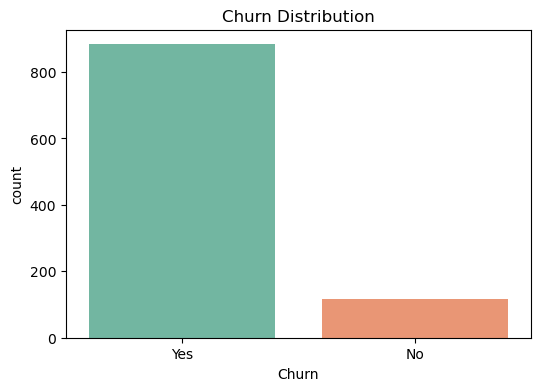

Churn
Yes    88.3
No     11.7
Name: proportion, dtype: float64

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts(normalize=True) * 100


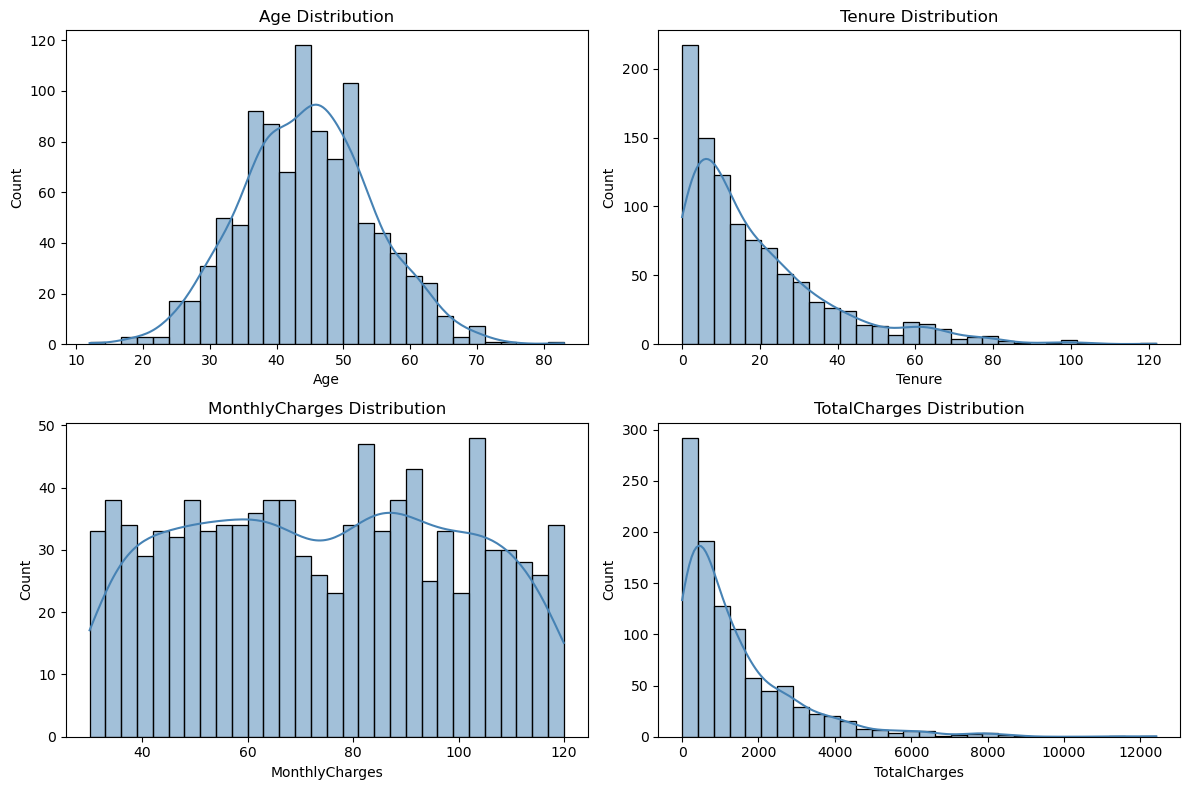

In [29]:
#Univariate Analysis (Numerical Variables)
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()


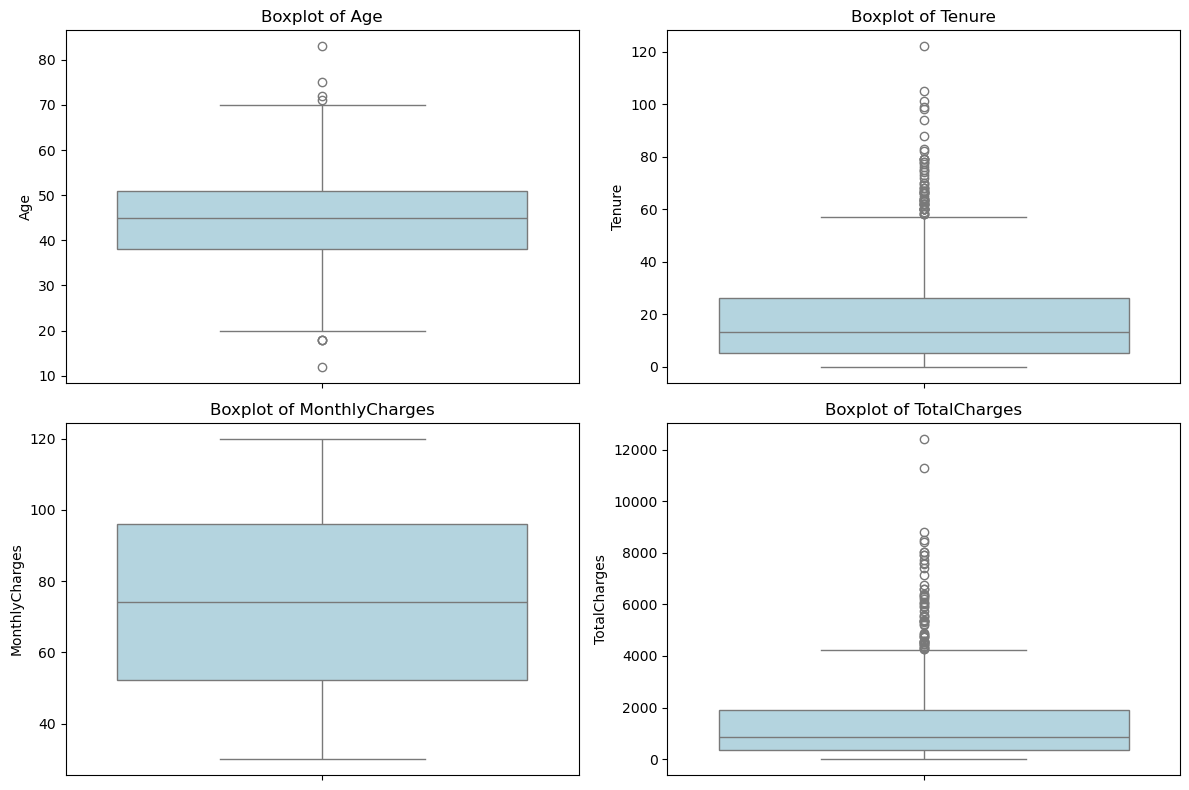

In [30]:
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


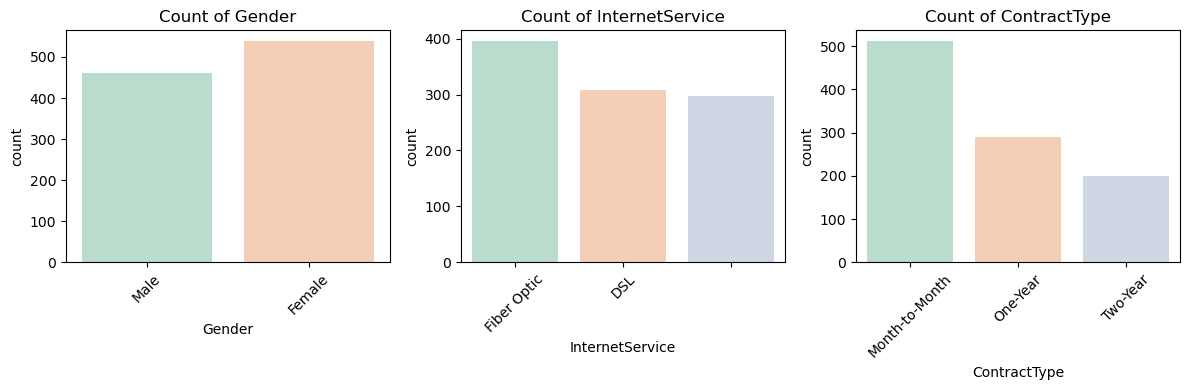

In [31]:
cat_cols = ['Gender', 'InternetService', 'ContractType']

plt.figure(figsize=(12,4))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1,3,i)
    sns.countplot(data=df, x=col, palette='Pastel2')
    plt.xticks(rotation=45)
    plt.title(f"Count of {col}")
plt.tight_layout()
plt.show()


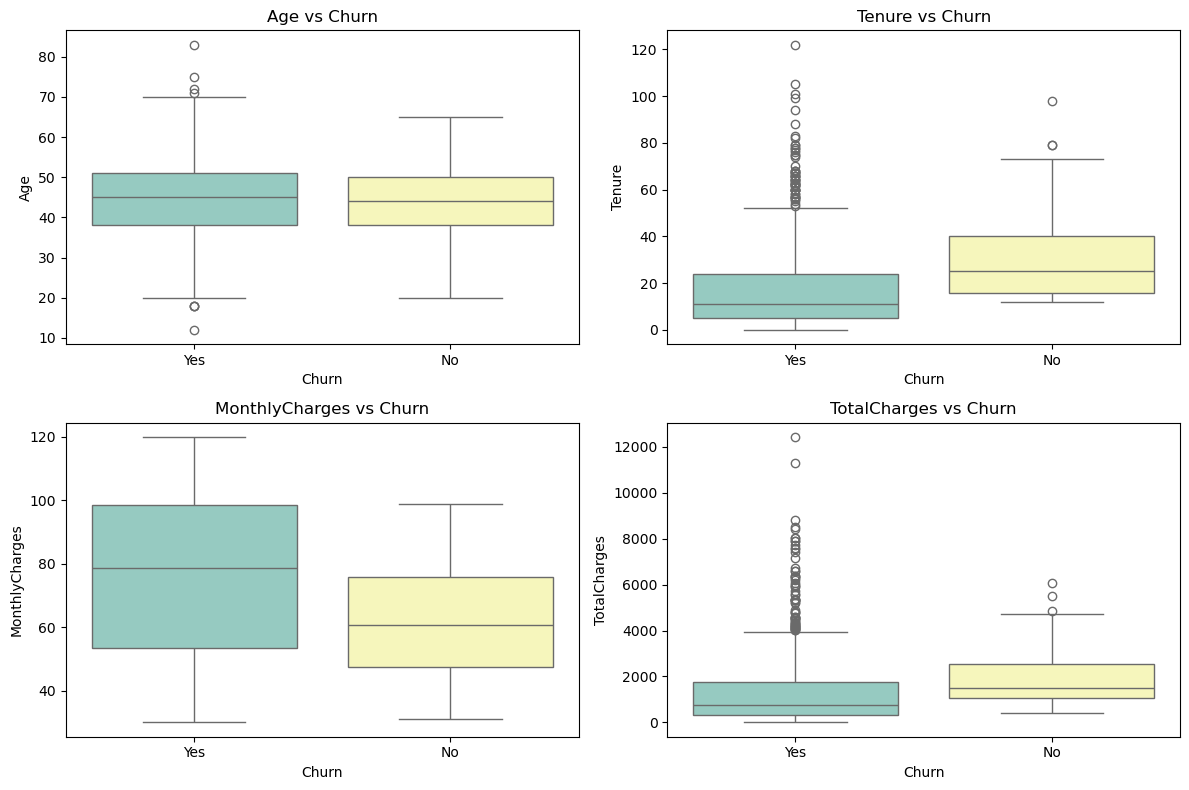

In [32]:
#Bivariate Analysis (Churn vs Numerical Features)

plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(data=df, x='Churn', y=col, palette='Set3')
    plt.title(f"{col} vs Churn")
plt.tight_layout()
plt.show()


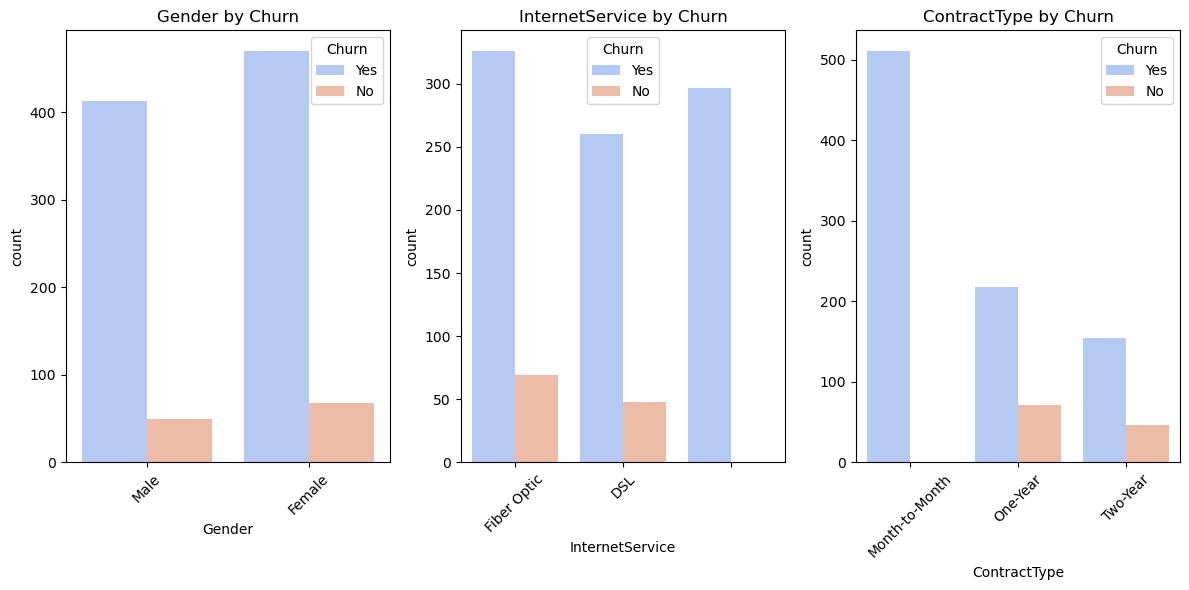

In [33]:
#Bivariate Analysis (Churn vs Categorical Features)

plt.figure(figsize=(12,6))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1,3,i)
    sns.countplot(data=df, x=col, hue='Churn', palette='coolwarm')
    plt.xticks(rotation=45)
    plt.title(f"{col} by Churn")
plt.tight_layout()
plt.show()


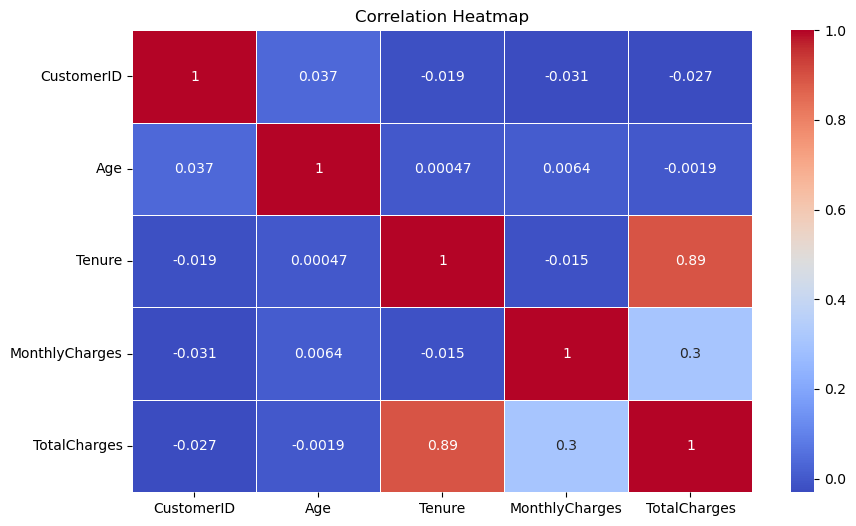

In [34]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [35]:
X['TotalCharges'] = np.log1p(X['TotalCharges'])

print(X[['TotalCharges']].head())

   TotalCharges
0      5.870426
1      0.000000
2      4.856551
3      6.708963
4      7.700440


Text(0.5, 1.0, 'After Log Transform: TotalCharges (log)')

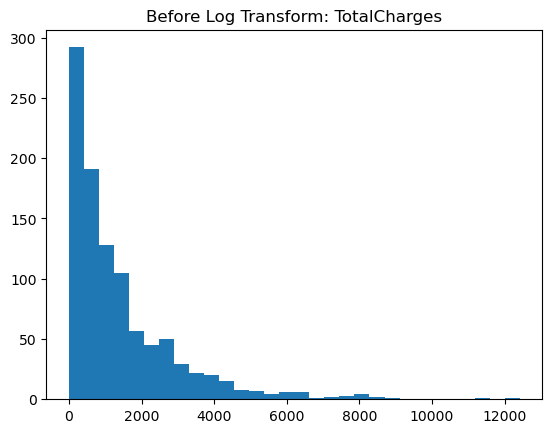

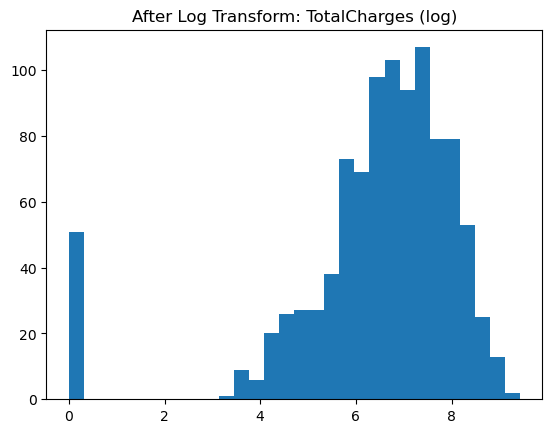

In [36]:
df['TotalCharges_log'] = np.log1p(df['TotalCharges'])

plt.figure()
plt.hist(df['TotalCharges'], bins=30)
plt.title("Before Log Transform: TotalCharges")
plt.figure()
plt.hist(df['TotalCharges_log'], bins=30)
plt.title("After Log Transform: TotalCharges (log)")

In [37]:
df.head(3)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn,TotalCharges_log
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes,5.870426
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes,0.000000
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes,4.856551


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

SMOTE (Synthetic Minority Over-sampling Technique)

In [39]:
# --- Data Balancing using SMOTE (Synthetic Minority Over-sampling Technique) ---
# Convert y_train and y_test to numeric labels (1=Yes, 0=No) for SMOTE and modeling compatibility
y_train_numeric = y_train['Churn'].map({'Yes': 1, 'No': 0})
y_test_numeric = y_test['Churn'].map({'Yes': 1, 'No': 0})

print("Original Churn distribution in training data (1=Yes, 0=No):")
print(y_train_numeric.value_counts())

# Apply SMOTE to the training data only
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train_numeric.values.ravel())

print("\nResampled training data shape:", X_train_resampled.shape, y_train_resampled.shape)
print("New balanced Churn distribution in training data (1=Yes, 0=No):")
print(pd.Series(y_train_resampled).value_counts())

Original Churn distribution in training data (1=Yes, 0=No):
Churn
1    706
0     94
Name: count, dtype: int64

Resampled training data shape: (1412, 5) (1412,)
New balanced Churn distribution in training data (1=Yes, 0=No):
1    706
0    706
Name: count, dtype: int64


Logistic Regression

In [40]:
lr_pipeline = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(random_state=42))])
param_dist_lr = {
    'lr__C': loguniform(0.001, 10),
}
lr_rand = RandomizedSearchCV(lr_pipeline, param_dist_lr, n_iter=20, cv=5, random_state=42, scoring='f1', n_jobs=-1)

lr_rand.fit(X_train_resampled, y_train_resampled) 
print("lr_rand best score:", lr_rand.best_score_)
print("lr_rand best parameters:", lr_rand.best_params_)

lr_rand best score: 0.7744558906809765
lr_rand best parameters: {'lr__C': np.float64(2.1368329072358767)}


In [41]:
best_lr = lr_rand.best_estimator_

# Using the default threshold (0.5) as the training data is now balanced by SMOTE
y_pred_lr = best_lr.predict(X_test)

print("\n--- Logistic Regression Report (Default Threshold 0.5) ---")
print("Test Accuracy:", accuracy_score(y_test_numeric, y_pred_lr))
print(classification_report(y_test_numeric, y_pred_lr))
print("F1-Score (Churn Class 1):", f1_score(y_test_numeric, y_pred_lr, pos_label=1))


--- Logistic Regression Report (Default Threshold 0.5) ---
Test Accuracy: 0.7
              precision    recall  f1-score   support

           0       0.25      0.83      0.39        23
           1       0.97      0.68      0.80       177

    accuracy                           0.70       200
   macro avg       0.61      0.75      0.59       200
weighted avg       0.89      0.70      0.75       200

F1-Score (Churn Class 1): 0.8013245033112583


Decision Tree

In [42]:
dt_pipeline = Pipeline([("scaler", StandardScaler()), ("dt", DecisionTreeClassifier(random_state=42))])
param_dist_dt = {
    'dt__max_depth': randint(1, 20),
    'dt__min_samples_leaf': randint(1, 5),
    'dt__min_samples_split': randint(2, 10)
}
dt_rand = RandomizedSearchCV(dt_pipeline, param_dist_dt, n_iter=20, cv=5, random_state=42, scoring='f1', n_jobs=-1)

dt_rand.fit(X_train_resampled, y_train_resampled) # UPDATED to use resampled data
print("dt_rand best score:", dt_rand.best_score_)
print("dt_rand best parameters:", dt_rand.best_params_)

dt_rand best score: 0.8702364068732557
dt_rand best parameters: {'dt__max_depth': 12, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}


In [43]:
best_dt = dt_rand.best_estimator_

y_pred_dt = best_dt.predict(X_test)


print("\n--- Decision Tree Report (Default Threshold 0.5) ---")
print("Test Accuracy:", accuracy_score(y_test_numeric, y_pred_dt))
print(classification_report(y_test_numeric, y_pred_dt))
print("F1-Score (Churn Class 1):", f1_score(y_test_numeric, y_pred_dt, pos_label=1))


--- Decision Tree Report (Default Threshold 0.5) ---
Test Accuracy: 0.735
              precision    recall  f1-score   support

           0       0.29      0.91      0.44        23
           1       0.98      0.71      0.83       177

    accuracy                           0.73       200
   macro avg       0.64      0.81      0.63       200
weighted avg       0.90      0.73      0.78       200

F1-Score (Churn Class 1): 0.8262295081967214


Random Forest

In [44]:
rf_pipeline = Pipeline([("scaler", StandardScaler()), ("rf", RandomForestClassifier(random_state=42))])
param_dist_rf = {
    'rf__n_estimators': randint(50, 200),
    'rf__max_depth': randint(1, 20),
    'rf__min_samples_leaf': randint(1, 5),
    'rf__min_samples_split': randint(2, 10)
}
rf_rand = RandomizedSearchCV(rf_pipeline, param_dist_rf, n_iter=20, cv=5, random_state=42, scoring='f1', n_jobs=-1)

rf_rand.fit(X_train_resampled, y_train_resampled) # UPDATED to use resampled data
print("rf_rand best score:", rf_rand.best_score_)
print("rf_rand best parameters:", rf_rand.best_params_)

best_rf = rf_rand.best_estimator_


rf_rand best score: 0.87870484097921
rf_rand best parameters: {'rf__max_depth': 15, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 4, 'rf__n_estimators': 157}


In [45]:
# Using the default threshold (0.5) as the training data is now balanced by SMOTE
y_pred_rf = best_rf.predict(X_test)

print("\n--- Random Forest Report (Default Threshold 0.5) ---")
print("Test Accuracy:", accuracy_score(y_test_numeric, y_pred_rf))
print(classification_report(y_test_numeric, y_pred_rf))
print("F1-Score (Churn Class 1):", f1_score(y_test_numeric, y_pred_rf, pos_label=1))


--- Random Forest Report (Default Threshold 0.5) ---
Test Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.35      0.83      0.49        23
           1       0.97      0.80      0.88       177

    accuracy                           0.80       200
   macro avg       0.66      0.81      0.68       200
weighted avg       0.90      0.80      0.83       200

F1-Score (Churn Class 1): 0.8757763975155279


Support Vector Classification (SVC)

In [46]:
# --- SVC Pipeline and Hyperparameter Search ---
# probability=True is required to get prediction probabilities later if needed
svc_pipeline = Pipeline([("scaler", StandardScaler()), ("svc", SVC(random_state=42, probability=True))])
param_dist_svc = {
    'svc__C': loguniform(0.01, 100),
    'svc__kernel': ['linear', 'rbf'], 
    'svc__gamma': loguniform(0.001, 1) 
}
svc_rand = RandomizedSearchCV(svc_pipeline, param_dist_svc, n_iter=20, cv=5, random_state=42, scoring='f1', n_jobs=-1)

svc_rand.fit(X_train_resampled, y_train_resampled) 
print("svc_rand best score:", svc_rand.best_score_)
print("svc_rand best parameters:", svc_rand.best_params_)
best_svc = svc_rand.best_estimator_

svc_rand best score: 0.8035039681060085
svc_rand best parameters: {'svc__C': np.float64(13.145103232150124), 'svc__gamma': np.float64(0.061737703947045704), 'svc__kernel': 'rbf'}


In [47]:
y_pred_svc = best_svc.predict(X_test)

print("\n--- SVC Report (Default Threshold 0.5) ---")
print("Test Accuracy:", accuracy_score(y_test_numeric, y_pred_svc))
print(classification_report(y_test_numeric, y_pred_svc))
print("F1-Score (Churn Class 1):", f1_score(y_test_numeric, y_pred_svc, pos_label=1))


--- SVC Report (Default Threshold 0.5) ---
Test Accuracy: 0.69
              precision    recall  f1-score   support

           0       0.24      0.78      0.37        23
           1       0.96      0.68      0.79       177

    accuracy                           0.69       200
   macro avg       0.60      0.73      0.58       200
weighted avg       0.88      0.69      0.75       200

F1-Score (Churn Class 1): 0.7947019867549668


K-Nearest Neighbors (KNN)

In [48]:
knn_pipeline = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
param_dist_knn = {
    'knn__n_neighbors': randint(1, 30), # Number of neighbors to use
    'knn__weights': ['uniform', 'distance'], # Weight function used in prediction
    'knn__p': [1, 2] # 1 for Manhattan distance, 2 for Euclidean distance
}
knn_rand = RandomizedSearchCV(knn_pipeline, param_dist_knn, n_iter=20, cv=5, random_state=42, scoring='f1', n_jobs=-1)

knn_rand.fit(X_train_resampled, y_train_resampled) 
print("knn_rand best score:", knn_rand.best_score_)
print("knn_rand best parameters:", knn_rand.best_params_)
best_knn = knn_rand.best_estimator_

knn_rand best score: 0.8575904100459504
knn_rand best parameters: {'knn__n_neighbors': 2, 'knn__p': 2, 'knn__weights': 'distance'}


In [49]:
y_pred_knn = best_knn.predict(X_test)

print("\n--- K-Nearest Neighbors Report (Default Threshold 0.5) ---")
print("Test Accuracy:", accuracy_score(y_test_numeric, y_pred_knn))
print(classification_report(y_test_numeric, y_pred_knn))
print("F1-Score (Churn Class 1):", f1_score(y_test_numeric, y_pred_knn, pos_label=1))


--- K-Nearest Neighbors Report (Default Threshold 0.5) ---
Test Accuracy: 0.805
              precision    recall  f1-score   support

           0       0.29      0.48      0.36        23
           1       0.93      0.85      0.88       177

    accuracy                           0.81       200
   macro avg       0.61      0.66      0.62       200
weighted avg       0.85      0.81      0.82       200

F1-Score (Churn Class 1): 0.8849557522123894


In [50]:
model_scores = {
    'LogisticRegression': lr_rand.best_score_,
    'DecisionTree': dt_rand.best_score_,
    'RandomForest': rf_rand.best_score_,
    'SVC': svc_rand.best_score_,
    'KNeighbors': knn_rand.best_score_
}

best_model_name = max(model_scores, key=model_scores.get)
best_score = model_scores[best_model_name]

if best_model_name == 'LogisticRegression':
    final_best_model = best_lr
elif best_model_name == 'DecisionTree':
    final_best_model = best_dt
elif best_model_name == 'RandomForest':
    final_best_model = best_rf
elif best_model_name == 'SVC':
    final_best_model = best_svc
elif best_model_name == 'KNeighbors':
    final_best_model = best_knn

print(f"The best model is the {best_model_name} with a cross-validation F1-score of: {best_score:.4f}")


model_filename = f"{best_model_name.lower()}_churn_model.pkl"
joblib.dump(final_best_model, model_filename)

print(f"Final best model pipeline successfully saved as: {model_filename}")

The best model is the RandomForest with a cross-validation F1-score of: 0.8787
Final best model pipeline successfully saved as: randomforest_churn_model.pkl
